In [ ]:
from datetime import datetime
import os
import pickle
import numpy as np
import pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from generation.surface_generation import generate_surfaces, SimulationConfig
from models.framework import DeepONet, MLP

# ============================================================
# 1️⃣ Generate synthetic Rough Bergomi IV surfaces
# ============================================================

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=2)
surfaces = generate_surfaces(
    num_sets=10,
    forward_curves_per_set=1,
    cfg=cfg,
    seed=42329,
    randomize_grid=True,
    model="rbergomi"
)

In [56]:
surfaces[5]["iv_surface"]

array([[0.47988263, 0.45273972, 0.4081812 , 0.38381746, 0.35585287,
        0.24561338, 0.16877064, 0.05121844, 0.07284765, 0.09957101,
        0.12097748, 0.1350745 , 0.17846906, 0.20445654, 0.23947608],
       [0.47178638, 0.44471815, 0.4002693 , 0.3759629 , 0.34806755,
        0.23832043, 0.16244455, 0.04952808, 0.07125421, 0.09793824,
        0.1192007 , 0.12907341, 0.16734476, 0.1917124 , 0.2245491 ],
       [0.4558799 , 0.4280631 , 0.3824412 , 0.3575505 , 0.3290656 ,
        0.21861593, 0.14524764, 0.04528596, 0.06742992, 0.09493469,
        0.11654487, 0.12651162, 0.14481243, 0.1583143 , 0.18543054],
       [0.44820097, 0.42042634, 0.37491304, 0.3501101 , 0.3217584 ,
        0.21233222, 0.14041299, 0.04404006, 0.06596136, 0.09342311,
        0.11497707, 0.12490328, 0.14311162, 0.15298255, 0.17653266],
       [0.4300939 , 0.40225476, 0.35679406, 0.33212394, 0.30403492,
        0.1971785 , 0.12906104, 0.04120874, 0.0624291 , 0.0898862 ,
        0.11150033, 0.12141727, 0.13925305, 


=== Simulator setup breakdown ===
rBergomi object init :   0.000 s
t-grid + dt setup    :   0.000 s
Brownian draws (W1,W2):   2.752 s
dB computation        :   0.250 s
Y computation (fBM)   :   1.546 s
TOTAL setup           :   4.548 s

=== Diagnostics for seed 400 ===
Simulator setup:       4.549 s
Xi0 mapping:           0.000 s
Path generation:       1.390 s
CMC integrals:         0.468 s
IV extraction total:   0.561 s (of which Brent inversions ≈   0.116 s)
TOTAL runtime:         6.968 s


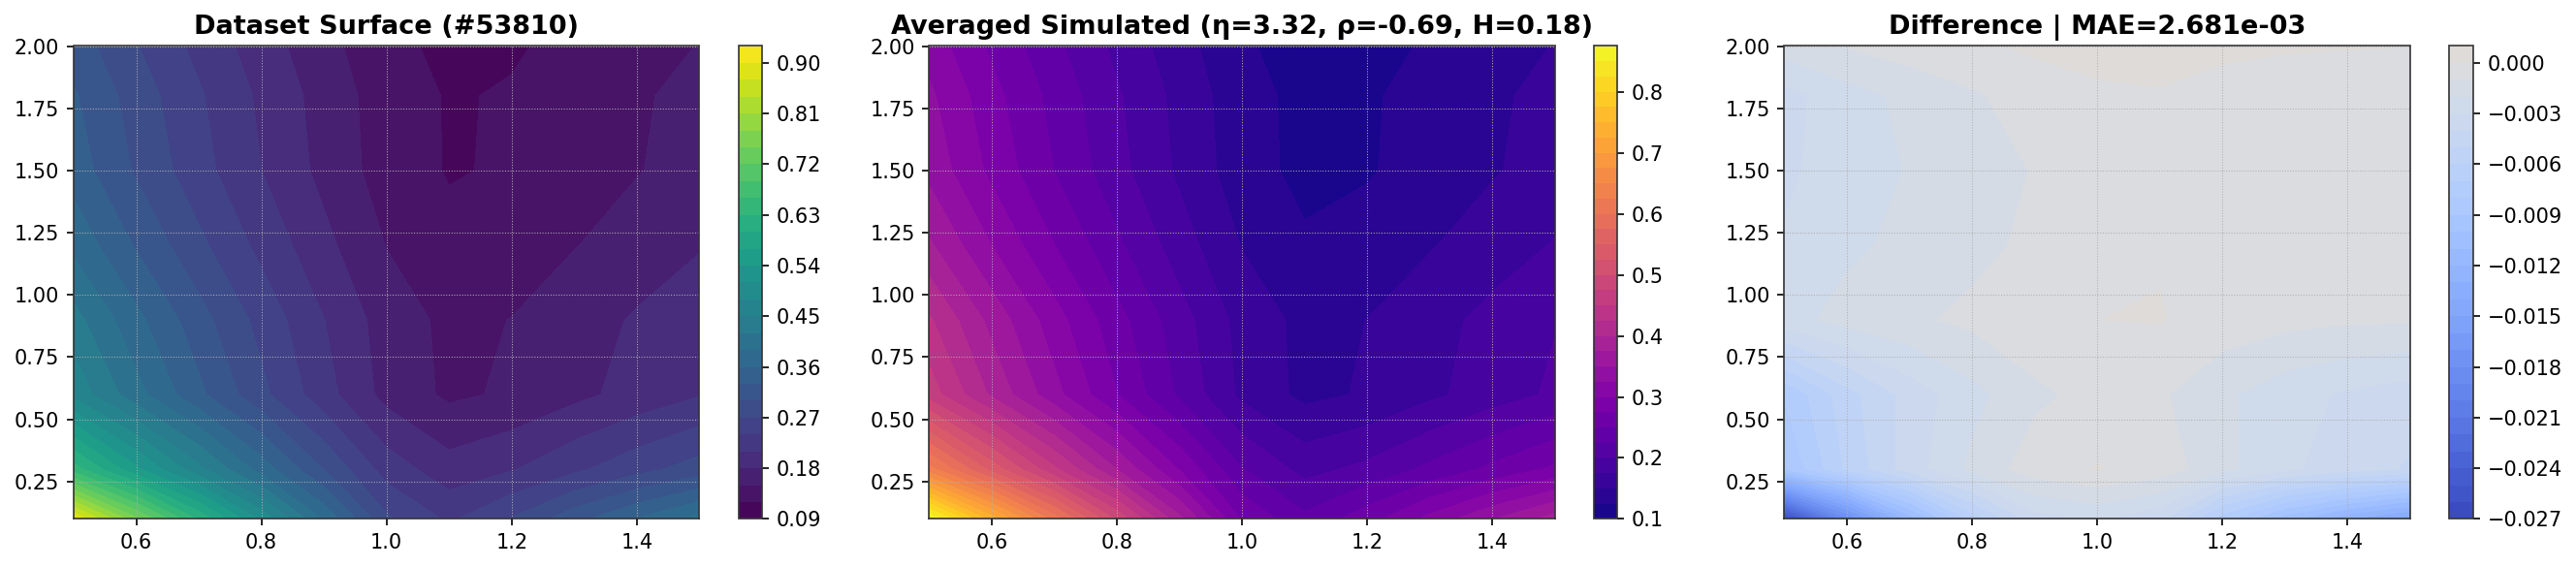

Comparison summary (averaged over seeds):
Idx 53810 | η=3.317, ρ=-0.692, H=0.184 | MAE=2.681e-03


In [2]:
import sys, os, gzip
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from generation.surface_generation import generate_fixed_surface, SimulationConfig

# ======================================================
# 1️⃣ Load data
# ======================================================

f = gzip.GzipFile("TrainrBergomiTermStructure.txt.gz", "r")
dat = np.load(f)
xx = dat[:, :11]
yy = dat[:, 11:]

strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)

# ======================================================
# 2️⃣ Define subset of parameter sets to test
# ======================================================
num_tests = 1        # number of parameter combinations to test
num_seeds = 1        # how many seeds to average over
np.random.seed(12346278)
test_indices = np.random.choice(len(xx), num_tests, replace=False)

# ======================================================
# 3️⃣ Run simulations and compare
# ======================================================
results = []
fig, axs = plt.subplots(num_tests, 3, figsize=(18, 4 * num_tests))
if num_tests == 1:
    axs = axs.reshape(1, -1)

for row, idx in enumerate(test_indices):
    xi0_knots = xx[idx, :8]
    eta, rho, H = xx[idx, 8:11]
    param_set = {"eta": float(eta), "rho": float(rho), "H": float(H)}

    # Average several random seeds
    sim_surfaces = []
    for s in range(num_seeds):
        seed_val = 400 + s * 17  # any deterministic spacing
        surf = generate_fixed_surface(param_set, xi0_knots, strikes, maturities, cfg, seed=seed_val)
        sim_surfaces.append(surf["iv_surface"])
    sim_surface = np.mean(sim_surfaces, axis=0)

    # True dataset surface
    true_surface = yy[idx].reshape(len(maturities), len(strikes))

    diff = sim_surface - true_surface
    mae = np.mean(np.abs(diff))
    results.append({"idx": idx, "eta": eta, "rho": rho, "H": H, "mae": mae})

    K, T = np.meshgrid(strikes, maturities)

    # Plot
    c0 = axs[row, 0].contourf(K, T, true_surface, levels=30, cmap="viridis")
    axs[row, 0].set_title(f"Dataset Surface (#{idx})")
    plt.colorbar(c0, ax=axs[row, 0])

    c1 = axs[row, 1].contourf(K, T, sim_surface, levels=30, cmap="plasma")
    axs[row, 1].set_title(f"Averaged Simulated (η={eta:.2f}, ρ={rho:.2f}, H={H:.2f})")
    plt.colorbar(c1, ax=axs[row, 1])

    vmax = np.max(np.abs(diff))
    c2 = axs[row, 2].contourf(K, T, diff, levels=30, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axs[row, 2].set_title(f"Difference | MAE={mae:.3e}")
    plt.colorbar(c2, ax=axs[row, 2])

plt.tight_layout()
plt.show()

# ======================================================
# 4️⃣ Print summary stats
# ======================================================
print("Comparison summary (averaged over seeds):")
for r in results:
    print(f"Idx {r['idx']:>4} | η={r['eta']:.3f}, ρ={r['rho']:.3f}, H={r['H']:.3f} | MAE={r['mae']:.3e}")


=== Simulator setup breakdown ===
rBergomi object init :   0.000 s
t-grid + dt setup    :   0.000 s
Brownian draws (W1,W2):   2.911 s
dB computation        :   0.000 s
Y computation (fBM)   :   1.720 s
TOTAL setup           :   4.632 s

=== Diagnostics for seed 400 ===
Simulator setup:       4.632 s
Xi0 mapping:           0.001 s
Path generation:       0.585 s
CMC integrals:         0.462 s
IV extraction total:   0.561 s (of which Brent inversions ≈   0.118 s)
TOTAL runtime:         6.240 s

Comparison summary (averaged over seeds):
Idx 53810 | η=3.317, ρ=-0.692, H=0.184 | MAE=2.681e-03







=== Simulator setup breakdown ===
rBergomi object init :   0.000 s
t-grid + dt setup    :   0.000 s
Brownian draws (W1,W2):   2.752 s
dB computation        :   0.250 s
Y computation (fBM)   :   1.546 s
TOTAL setup           :   4.548 s

=== Diagnostics for seed 400 ===
Simulator setup:       4.549 s
Xi0 mapping:           0.000 s
Path generation:       1.390 s
CMC integrals:         0.468 s
IV extraction total:   0.561 s (of which Brent inversions ≈   0.116 s)
TOTAL runtime:         6.968 s

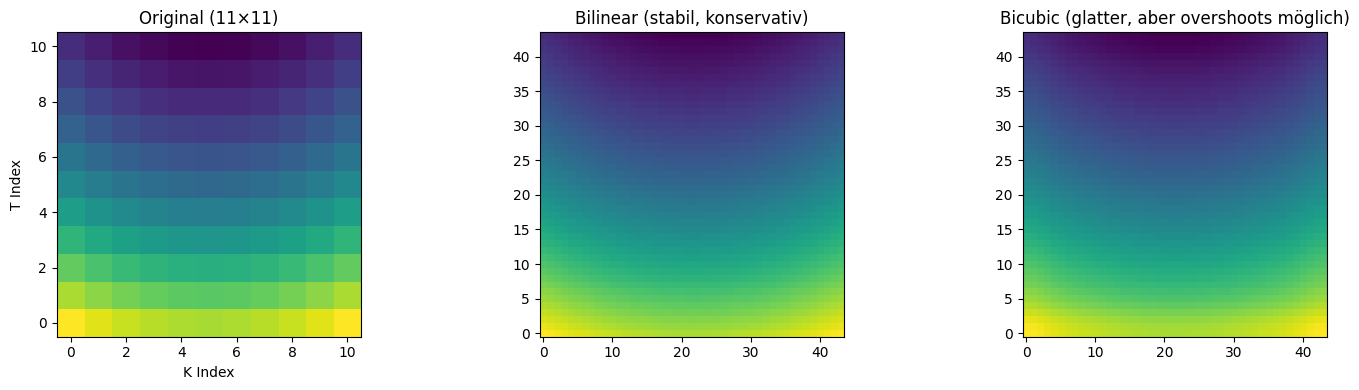

Beispiel bilinear interpolierter Wert: 0.22339512943698403


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# ---------------------------------------------------------------------
# 1. Eigene Bilinear-Interpolation (für Einzelpunkte)
# ---------------------------------------------------------------------
def bilinear_interpolate(Z, x, y):
    """
    Bilinear interpolation of a 2D surface Z at fractional coordinates (x, y).
    Coordinates x = column index, y = row index.
    """

    x0 = int(np.floor(x))
    x1 = x0 + 1
    y0 = int(np.floor(y))
    y1 = y0 + 1

    # Boundary clamp
    x0 = np.clip(x0, 0, Z.shape[1]-1)
    x1 = np.clip(x1, 0, Z.shape[1]-1)
    y0 = np.clip(y0, 0, Z.shape[0]-1)
    y1 = np.clip(y1, 0, Z.shape[0]-1)

    # Distances
    dx = x - x0
    dy = y - y0

    # Four surrounding grid points
    Q00 = Z[y0, x0]
    Q10 = Z[y0, x1]
    Q01 = Z[y1, x0]
    Q11 = Z[y1, x1]

    # Bilinear formula
    return (
        Q00 * (1-dx) * (1-dy) +
        Q10 *    dx  * (1-dy) +
        Q01 * (1-dx) *    dy  +
        Q11 *    dx  *    dy
    )


# ---------------------------------------------------------------------
# 2. Beispiel-Surface erzeugen (IV-Surface-artig)
# ---------------------------------------------------------------------
K = np.linspace(0.8, 1.2, 11)
T = np.linspace(0.1, 1.0, 11)
KK, TT = np.meshgrid(K, T)

# künstlich glatte IV-Surface
iv = 0.20 + 0.1*(KK - 1)**2 + 0.05*np.exp(-TT)

# ---------------------------------------------------------------------
# 3. Interpolation: bilinear vs. bicubic
# ---------------------------------------------------------------------
iv_bilinear = zoom(iv, zoom=4, order=1)  # Bilinear (order=1)
iv_bicubic  = zoom(iv, zoom=4, order=3)  # Bicubic  (order=3)


# ---------------------------------------------------------------------
# 4. Plot Vergleich
# ---------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15,4))

ax[0].imshow(iv, cmap="viridis", origin="lower")
ax[0].set_title("Original (11×11)")
ax[0].set_xlabel("K Index")
ax[0].set_ylabel("T Index")

ax[1].imshow(iv_bilinear, cmap="viridis", origin="lower")
ax[1].set_title("Bilinear (stabil, konservativ)")

ax[2].imshow(iv_bicubic, cmap="viridis", origin="lower")
ax[2].set_title("Bicubic (glatter, aber overshoots möglich)")

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# 5. Demonstration einzelner bilinear Punkte
# ---------------------------------------------------------------------
# Beispiel: Interpoliere bei x=3.2, y=7.6 im coarse Grid
demo_value = bilinear_interpolate(iv, x=3.2, y=7.6)
print("Beispiel bilinear interpolierter Wert:", demo_value)
